# Forecasting Models

- We use Amtrak.csv dataset
- We implement regression-based forecasting models
- We will immplement smoothing methods to forecast the Amtrak ridership
- Reference: **Data Mining for Business Analytics** (Shumueli et al., Wiley)

## Time Series data

In [ ]:
#mount google drive to read data
dataFile = 'Amtrak.csv'

import pandas as pd
from google.colab import data_table
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/DSBA6211_DATA/'+ dataFile
df = pd.read_csv(path,sep=",",)
drive.flush_and_unmount()
df.describe(include='all').T

Mounted at /content/drive


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Month,159,159,1/1/1991,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ridership,159.0,NaN,NaN,NaN,1822.197208,181.636034,1360.852,1698.5645,1831.049,1966.9575,2223.349


In [ ]:
# Display data frame and check the data types
display(df)
df.dtypes

,Month,Ridership
0,1/1/1991,1708.917
1,1/2/1991,1620.586
2,1/3/1991,1972.715
3,1/4/1991,1811.665
4,1/5/1991,1974.964
...,...,...
154,1/11/2003,2076.054
155,1/12/2003,2140.677
156,1/1/2004,1831.508
157,1/2/2004,1838.006


,0
Month,object
Ridership,float64


In [ ]:
# Convert the Month column to time series
df['Date']= pd.to_datetime(df['Month'], format='%d/%m/%Y')
rider_ts = pd.Series(df.Ridership.values, index=df.Date, name='Ridership')

In [ ]:
# Display the time series data (pandas.Series object)
print(type(rider_ts))
print(rider_ts)

<class 'pandas.core.series.Series'>
Date
1991-01-01    1708.917
1991-02-01    1620.586
1991-03-01    1972.715
1991-04-01    1811.665
1991-05-01    1974.964
                ...   
2003-11-01    2076.054
2003-12-01    2140.677
2004-01-01    1831.508
2004-02-01    1838.006
2004-03-01    2132.446
Name: Ridership, Length: 159, dtype: float64


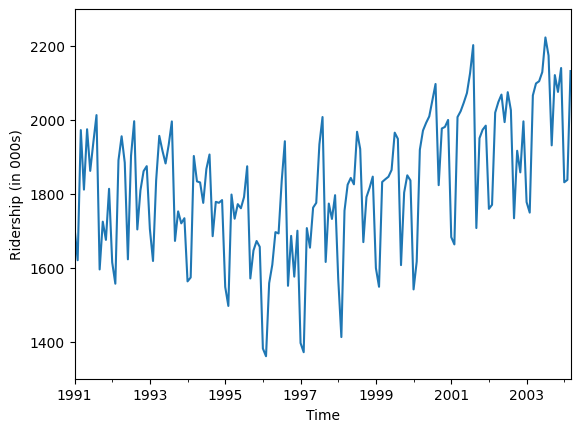

In [ ]:
# Plot the time series
# Have you observed any trend and seasonality in the plot?
import matplotlib.pylab as plt
ax = rider_ts.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Ridership (in 000s)')
ax.set_ylim(1300,2300)
plt.show()

The code below provided performs time series decomposition, breaking down the original series into its fundamental components. This helps uncover underlying patterns in the data. Here's a detailed explanation of each part:

**Decomposition:**

The `seasonal_decompose` function from `statsmodels` decomposes a time series into three main components:

- **Trend:** The long-term progression in the data.
- **Seasonal:** Repeating patterns or cycles over a fixed period (e.g., monthly or quarterly).
- **Residual:** The remaining random variation after removing the trend and seasonal components.

The command `sd.plot()` generates a visualization with four subplots, showing:

1. The **Original** time series.
2. The **Trend** component, which reflects long-term changes in the data.
3. The **Seasonal** component, capturing regular patterns or cycles.
4. The **Residuals (or Noise),** representing random variations that are not explained by the trend or seasonal components.

This visualization is valuable for identifying whether the time series exhibits a clear trend or seasonality. It also aids in selecting suitable forecasting models, particularly if seasonality- or trend-based models are appropriate.

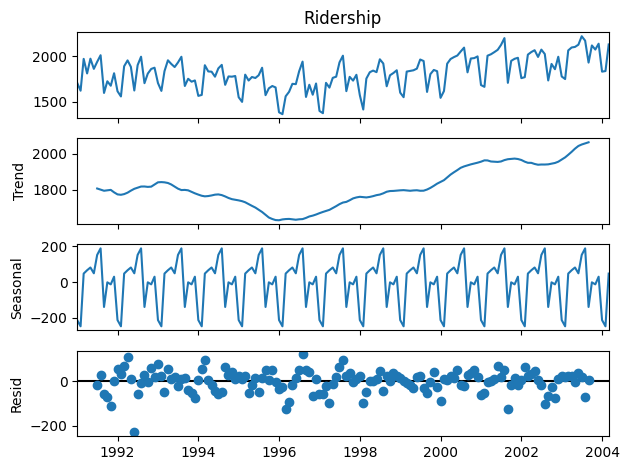

In [ ]:
# Seasonal Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
sd = seasonal_decompose(rider_ts, model='additive', period=12)

# This will create a single decomposition plot with 4 subplots
sd.plot()
plt.show()

In [ ]:
# Data partition for the time series data
# Keep the last three years data as the validation dataset
nValid = 36
nTrain = len(rider_ts) - nValid
train_ts = rider_ts[:nTrain]
valid_ts = rider_ts[nTrain:]


## Model 1: A linear trend time series model

In [ ]:
import statsmodels.formula.api as sm
from statsmodels.tsa import tsatools, stattools
# Add a trend term to the time series
ts_df = tsatools.add_trend(rider_ts,trend='ct')
# Add a month term to the time series
ts_df['Month']=ts_df.index.month
nValid = 36
nTrain = len(rider_ts) - nValid
train_df = ts_df[:nTrain]
valid_df = ts_df[nTrain:]
rider_lm = sm.ols(formula='Ridership ~ trend',data=train_df).fit()

In [ ]:
# Display updated df
ts_df

,Ridership,const,trend,Month
Date,,,,
1991-01-01,1708.917,1.0,1.0,1
1991-02-01,1620.586,1.0,2.0,2
1991-03-01,1972.715,1.0,3.0,3
1991-04-01,1811.665,1.0,4.0,4
1991-05-01,1974.964,1.0,5.0,5
...,...,...,...,...
2003-11-01,2076.054,1.0,155.0,11
2003-12-01,2140.677,1.0,156.0,12
2004-01-01,1831.508,1.0,157.0,1


In [ ]:
# Display the linear model result
rider_lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Ridership   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7456
Date:                Tue, 24 Mar 2026   Prob (F-statistic):              0.390
Time:                        21:00:03   Log-Likelihood:                -797.95
No. Observations:                 123   AIC:                             1600.
Df Residuals:                     121   BIC:                             1606.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1750.3595     29.073     60.206      0.000    1692.802    1807.917
trend          0.3514      0.407      0.864      0.390      -0.454       1.157
==============================================================================
Omnibus:                        4.293   Durbin-Watson:                   1.110
Prob(Omnibus):                  0.117   Jarque-Bera (JB):                4.340
Skew:                          -0.435   Prob(JB):                        0.114
Kurtosis:                       2.700   Cond. No.                         144.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Model performance
using the mlba (https://pypi.org/project/mlba/) package

In [ ]:
# Evaluate Model1 performance
! pip install dmba
from dmba import regressionSummary
predict_lm = rider_lm.predict(valid_df)
regressionSummary(valid_ts,predict_lm)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 97.2 MB/s eta 0:00:00
Colab environment detected.

Regression statistics

                      Mean Error (ME) : 193.1316
       Root Mean Squared Error (RMSE) : 239.4863
            Mean Absolute Error (MAE) : 209.4371
          Mean Percentage Error (MPE) : 9.2099
Mean Absolute Percentage Error (MAPE) : 10.1477


### Model Performance Functions
can be easily created based on the definitions.

In [ ]:
import numpy as np
def mean_error(actual, predicted):
    return np.mean(actual - predicted)

def mpe(actual, predicted):
    return np.mean((actual - predicted) / actual)

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def rsquared(actual, predicted):
    return 1 - np.sum((actual - predicted) ** 2) / np.sum((actual - actual.mean()) ** 2)


# Create a dictionary with performance metrics
def model_performance(actual, predicted):
    return {
        'ME': round(mean_error(actual, predicted), 4),
        'RMSE': round(rmse(actual, predicted), 4),
        'MAE': round(mae(actual, predicted), 4),
        'MPE': round(mpe(actual, predicted), 4),
        'MAPE': round(mape(actual, predicted), 4),
        'R-squared': round(rsquared(actual, predicted), 4)
    }

### Model 1 performance

In [ ]:
pd.Series(model_performance(valid_ts,predict_lm), name = "Performance")

,Performance
ME,193.1316
RMSE,239.4863
MAE,209.4371
MPE,0.0921
MAPE,10.1477
R-squared,-1.8446


## Model 2: A polynomial trend time series model

In [ ]:
import numpy as np
rider_lm_poly = sm.ols(formula='Ridership ~ trend + np.square(trend)',
data=train_df).fit()

In [ ]:
# Display the polynomial trend model result
rider_lm_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Ridership   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.136
Method:                 Least Squares   F-statistic:                     10.58
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           5.84e-05
Time:                        15:11:03   Log-Likelihood:                -788.33
No. Observations:                 123   AIC:                             1583.
Df Residuals:                     120   BIC:                             1591.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1888.8840     40.915     46.166      0.000    1807.875    1969.893
trend               -6.2978      1.523     -4.134      0.000      -9.314      -3.282
np.square(trend)     0.0536      0.012      4.506      0.000       0.030       0.077
==============================================================================
Omnibus:                        7.384   Durbin-Watson:                   1.298
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                7.185
Skew:                          -0.540   Prob(JB):                       0.0275
Kurtosis:                       2.516   Cond. No.                     2.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model 2 performance

In [ ]:
predict_lm_poly = rider_lm_poly.predict(valid_df)
regressionSummary(valid_ts,predict_lm_poly)
pd.Series(model_performance(valid_ts,predict_lm_poly), name = "Performance")


Regression statistics

                      Mean Error (ME) : -83.9621
       Root Mean Squared Error (RMSE) : 179.8494
            Mean Absolute Error (MAE) : 133.7383
          Mean Percentage Error (MPE) : -4.7254
Mean Absolute Percentage Error (MAPE) : 7.0757


,Performance
ME,-83.9621
RMSE,179.8494
MAE,133.7383
MPE,-0.0473
MAPE,7.0757
R-squared,-0.6043


## Model 3: An additive seasonality model

In [ ]:
rider_lm_season = sm.ols(formula='Ridership~C(Month)',data=train_df).fit()
rider_lm_season.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Ridership   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     17.54
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           1.20e-19
Time:                        15:11:15   Log-Likelihood:                -736.38
No. Observations:                 123   AIC:                             1497.
Df Residuals:                     111   BIC:                             1531.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1573.9722     30.578     51.475      0.000    1513.381    1634.564
C(Month)[T.2]    -42.9302     43.243     -0.993      0.323    -128.620      42.759
C(Month)[T.3]    260.7677     43.243      6.030      0.000     175.078     346.457
C(Month)[T.4]    245.0919     44.311      5.531      0.000     157.286     332.897
C(Month)[T.5]    278.2222     44.311      6.279      0.000     190.417     366.028
C(Month)[T.6]    233.4598     44.311      5.269      0.000     145.654     321.265
C(Month)[T.7]    345.3265     44.311      7.793      0.000     257.521     433.132
C(Month)[T.8]    396.6595     44.311      8.952      0.000     308.854     484.465
C(Month)[T.9]     75.7615     44.311      1.710      0.090     -12.044     163.567
C(Month)[T.10]   200.6076     44.311      4.527      0.000     112.802     288.413
C(Month)[T.11]   192.3552     44.311      4.341      0.000     104.550     280.161
C(Month)[T.12]   230.4151     44.311      5.200      0.000     142.610     318.221
==============================================================================
Omnibus:                        0.495   Durbin-Watson:                   0.386
Prob(Omnibus):                  0.781   Jarque-Bera (JB):                0.452
Skew:                          -0.145   Prob(JB):                        0.798
Kurtosis:                       2.937   Cond. No.                         12.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

###  Model 3 performance

In [ ]:
predict_lm_season = rider_lm_season.predict(valid_df)
regressionSummary(valid_ts, predict_lm_season)
pd.Series(model_performance(valid_ts,predict_lm_season), name = "Performance")


Regression statistics

                      Mean Error (ME) : 217.9267
       Root Mean Squared Error (RMSE) : 229.6509
            Mean Absolute Error (MAE) : 217.9267
          Mean Percentage Error (MPE) : 10.8646
Mean Absolute Percentage Error (MAPE) : 10.8646


,Performance
ME,217.9267
RMSE,229.6509
MAE,217.9267
MPE,0.1086
MAPE,10.8646
R-squared,-1.6157


## Model 4: A model with polynomial trend and seasonality

In [ ]:
modelfomula = 'Ridership ~ trend + np.square(trend) + C(Month)'
rider_lm_trendseason = sm.ols(formula=modelfomula, data=train_df).fit()
rider_lm_trendseason.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Ridership   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     39.42
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           3.75e-35
Time:                        15:11:27   Log-Likelihood:                -691.27
No. Observations:                 123   AIC:                             1411.
Df Residuals:                     109   BIC:                             1450.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1696.9794     27.675     61.318      0.000    1642.128    1751.831
C(Month)[T.2]      -43.2458     30.241     -1.430      0.156    -103.182      16.690
C(Month)[T.3]      260.0149     30.242      8.598      0.000     200.076     319.954
C(Month)[T.4]      260.6175     31.021      8.401      0.000     199.135     322.100
C(Month)[T.5]      293.7966     31.020      9.471      0.000     232.316     355.278
C(Month)[T.6]      248.9615     31.020      8.026      0.000     187.481     310.442
C(Month)[T.7]      360.6340     31.020     11.626      0.000     299.153     422.115
C(Month)[T.8]      411.6513     31.021     13.270      0.000     350.169     473.134
C(Month)[T.9]       90.3162     31.022      2.911      0.004      28.831     151.801
C(Month)[T.10]     214.6037     31.024      6.917      0.000     153.115     276.092
C(Month)[T.11]     205.6711     31.026      6.629      0.000     144.178     267.165
C(Month)[T.12]     242.9294     31.029      7.829      0.000     181.430     304.429
trend               -7.1559      0.729     -9.812      0.000      -8.601      -5.710
np.square(trend)     0.0607      0.006     10.660      0.000       0.049       0.072
==============================================================================
Omnibus:                        7.382   Durbin-Watson:                   0.791
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                6.974
Skew:                          -0.529   Prob(JB):                       0.0306
Kurtosis:                       3.492   Cond. No.                     8.24e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.24e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model 4 performance

In [ ]:
predict_lm_trendseason = rider_lm_trendseason.predict(valid_df)
predict_lm_trendseason_train = rider_lm_trendseason.predict(train_df) # Perrormance on train set
regressionSummary(valid_ts,predict_lm_trendseason)
pd.DataFrame({'Train': model_performance(train_ts,predict_lm_trendseason_train),
              'Validation': model_performance(valid_ts,predict_lm_trendseason)})


Regression statistics

                      Mean Error (ME) : -126.1654
       Root Mean Squared Error (RMSE) : 153.2507
            Mean Absolute Error (MAE) : 131.7250
          Mean Percentage Error (MPE) : -6.4315
Mean Absolute Percentage Error (MAPE) : 6.6987


,Train,Validation
ME,0.0000,-126.1654
RMSE,66.7614,153.2507
MAE,51.9509,131.7250
MPE,-0.0015,-0.0643
MAPE,3.0155,6.6987
R-squared,0.8246,-0.1648


### Visualize Model 4

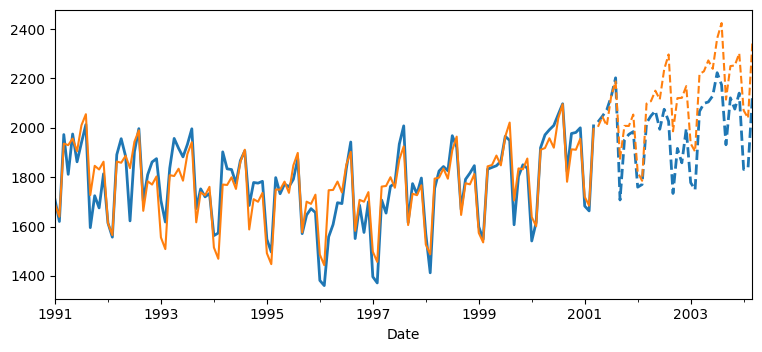

In [ ]:
# Blue line for the original time series
# Orange line for the forecasted time series
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(9,3.75))
train_df.plot(y='Ridership',ax=ax,color='C0',linewidth=2)
valid_df.plot(y='Ridership',ax=ax,color='C0',linewidth=2, linestyle='dashed')
rider_lm_trendseason.predict(train_df).plot(color='C1')
rider_lm_trendseason.predict(valid_df).plot(color='C1',linestyle='dashed')
ax.get_legend().remove()
plt.show()


## Model 5: A simple moving average model

In [ ]:
# For example, if rolling window=12, we will use the previous 11 periods average
# to forecast the 12th period
ma = train_ts.rolling(12).mean()

In [ ]:
# Obtain the last moving average in the traing period
last_ma = ma[-1]

/tmp/ipykernel_2967/3370203541.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  last_ma = ma[-1]


In [ ]:
train_ts

,Ridership
Date,
1991-01-01,1708.917
1991-02-01,1620.586
1991-03-01,1972.715
1991-04-01,1811.665
1991-05-01,1974.964
...,...
2000-11-01,1981.408
2000-12-01,2000.153
2001-01-01,1683.148


In [ ]:
ma

,Ridership
Date,
1991-01-01,NaN
1991-02-01,NaN
1991-03-01,NaN
1991-04-01,NaN
1991-05-01,NaN
...,...
2000-11-01,1901.808000
2000-12-01,1915.451167
2001-01-01,1927.241833


In [ ]:
last_ma

np.float64(1938.4806666666666)

In [ ]:
# Forecasting based on last_ma
predict_ma = pd.Series(last_ma,index=valid_ts.index)
predict_ma

,0
Date,
2001-04-01,1938.480667
2001-05-01,1938.480667
2001-06-01,1938.480667
2001-07-01,1938.480667
2001-08-01,1938.480667
2001-09-01,1938.480667
2001-10-01,1938.480667
2001-11-01,1938.480667
2001-12-01,1938.480667


### Model 5 performance

In [ ]:
regressionSummary(valid_ts, predict_ma)
pd.Series(model_performance(valid_ts,predict_ma), name = "Performance")


Regression statistics

                      Mean Error (ME) : 54.7296
       Root Mean Squared Error (RMSE) : 152.1767
            Mean Absolute Error (MAE) : 135.1550
          Mean Percentage Error (MPE) : 2.2278
Mean Absolute Percentage Error (MAPE) : 6.7771


,Performance
ME,54.7296
RMSE,152.1767
MAE,135.1550
MPE,0.0223
MAPE,6.7771
R-squared,-0.1486


## Model 6: Simple exponential smoothing

In [ ]:
# https://www.statsmodels.org/dev/generated/statsmodels.tsa.holtwinters.ExponentialSmoothing.html

from statsmodels.tsa.api import SimpleExpSmoothing
SES = SimpleExpSmoothing(train_ts, initialization_method='estimated').fit()
predict_SES = SES.forecast(len(valid_ts))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
predict_SES # Note that all forecasts are the same value

,0
2001-04-01,1884.207889
2001-05-01,1884.207889
2001-06-01,1884.207889
2001-07-01,1884.207889
2001-08-01,1884.207889
2001-09-01,1884.207889
2001-10-01,1884.207889
2001-11-01,1884.207889
2001-12-01,1884.207889
2002-01-01,1884.207889


### ES parameters

In [ ]:
# Alpha and initial level are estimated by minimizing SSE
# Check the optimal model parameters
SES.model.params

{'smoothing_level': 0.1383046949684767,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 1802.0218788177413,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

### Model 6 performance

In [ ]:
regressionSummary(valid_ts,predict_SES)
pd.Series(model_performance(valid_ts,predict_SES), name = "Performance")


Regression statistics

                      Mean Error (ME) : 109.0024
       Root Mean Squared Error (RMSE) : 179.0082
            Mean Absolute Error (MAE) : 160.6923
          Mean Percentage Error (MPE) : 4.9651
Mean Absolute Percentage Error (MAPE) : 7.9063


,Performance
ME,109.0024
RMSE,179.0082
MAE,160.6923
MPE,0.0497
MAPE,7.9063
R-squared,-0.5893
